# EDA Stress Classification — Mamba-2 (Pure PyTorch)
**Train**: CATSA (90/10 subject split, all 5 tasks)  
**Test**: EmpaticaE4Stress (subject_01~06, cross-dataset)  
**Signal**: EDA — univariate, 4 Hz  
**Window**: 240 samples (60 s), stride 40 (10 s)  
**Model**: CNN frontend → 3× Mamba-2 blocks → classification head

In [2]:
import os, glob, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ── constants ──────────────────────────────────────────────────────────────
EDA_FS      = 4
WINDOW_SIZE = EDA_FS * 60   # 240
STRIDE      = EDA_FS * 10   # 40
BATCH_SIZE  = 64
LR          = 1e-3
EPOCHS      = 50
SAVE_DIR    = 'Save_model_Mamba2'
os.makedirs(SAVE_DIR, exist_ok=True)

CATSA_ROOT = '/home/binghin2/Myproject/Dataset/CATSA'
E4_ROOT    = '/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects'
TASKS      = ['Baseline', 'Logic', 'Nback', 'Stroop', 'Sudoku']

# ── CATSA utilities ────────────────────────────────────────────────────────
def read_eda(path):
    df  = pd.read_csv(path)
    nc  = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not nc:
        return np.array([], dtype=np.float32)
    vals = df[nc[0]].to_numpy(np.float32)
    return vals[~np.isnan(vals)]

def make_windows_1d(sig, W, S):
    segs = [sig[i:i+W] for i in range(0, len(sig)-W+1, S)]
    if not segs:
        return np.empty((0, 1, W), dtype=np.float32)
    return np.asarray(segs, dtype=np.float32)[:, None, :]  # [B,1,W]

def label_for_task(task):
    return 0 if task == 'Baseline' else 1

def collect_catsa_subject(sub_dir):
    X, y = [], []
    sig_all = []
    for task in TASKS:
        p = os.path.join(sub_dir, task, 'EDA.csv')
        if os.path.exists(p):
            sig_all.append(read_eda(p))
    if not sig_all:
        return None, None
    full = np.concatenate(sig_all)
    mu, sd = full.mean(), full.std() + 1e-8
    for task in TASKS:
        p = os.path.join(sub_dir, task, 'EDA.csv')
        if not os.path.exists(p):
            continue
        sig = (read_eda(p) - mu) / sd
        wins = make_windows_1d(sig, WINDOW_SIZE, STRIDE)
        if wins.shape[0] == 0:
            continue
        lbl = label_for_task(task)
        X.append(wins)
        y.append(np.full(wins.shape[0], lbl, dtype=np.int64))
    if not X:
        return None, None
    return np.concatenate(X), np.concatenate(y)

def build_catsa_split(val_ratio=0.1):
    subs = sorted(glob.glob(os.path.join(CATSA_ROOT, 'Sub*')))
    random.shuffle(subs)
    n_val = max(1, int(len(subs) * val_ratio))
    val_subs, train_subs = subs[:n_val], subs[n_val:]
    def gather(sublist):
        Xs, ys = [], []
        for s in sublist:
            X, y = collect_catsa_subject(s)
            if X is not None:
                Xs.append(X); ys.append(y)
        return np.concatenate(Xs), np.concatenate(ys)
    return gather(train_subs), gather(val_subs)

class EDADataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# ── Focal Loss ─────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction='none')
        pt  = torch.exp(-ce)
        fl  = (1 - pt) ** self.gamma * ce
        if self.alpha is not None:
            at  = self.alpha.to(logits.device)[targets]
            fl  = at * fl
        return fl.mean()

# ── EmpaticaE4 protocol ────────────────────────────────────────────────────
def build_e4_labels(n, fs=EDA_FS):
    # 분(minute)이 아닌 초(second) 단위로 수정
    fixed_s = {'rest0':180, 'task1':600, 'rest1':120, 'task2':300, 'rest2':120,
               'task3':180, 'rest3':120, 'task5':60, 'rest5':120}
    
    total_fixed_s = sum(fixed_s.values())
    task4_s = max(0, n // fs - total_fixed_s)
    
    seg = [
        ('rest0', fixed_s['rest0'] * fs, 0),
        ('task1', fixed_s['task1'] * fs, 1),
        ('rest1', fixed_s['rest1'] * fs, -1),
        ('task2', fixed_s['task2'] * fs, 1),
        ('rest2', fixed_s['rest2'] * fs, -1),
        ('task3', fixed_s['task3'] * fs, 1),
        ('rest3', fixed_s['rest3'] * fs, -1),
        ('task4', task4_s * fs, 1),
        ('task5', fixed_s['task5'] * fs, 1),
        ('rest5', fixed_s['rest5'] * fs, -1),
    ]
    
    labels = np.full(n, -1, dtype=np.int64)
    cur = 0
    for _, length, lbl in seg:
        end = min(cur + length, n)
        if lbl >= 0:
            labels[cur:end] = lbl
        cur = end
    return labels

def normalize_subject_eda(sig):
    mu, sd = sig.mean(), sig.std() + 1e-8
    return (sig - mu) / sd

def collect_e4_subject(sub_path):
    eda_path = os.path.join(sub_path, 'EDA.csv')
    if not os.path.exists(eda_path):
        return None, None
    sig  = read_eda(eda_path)
    lbl  = build_e4_labels(len(sig), EDA_FS)
    
    # 정규화: 라벨이 있는 구간(-1 제외)의 평균/표준편차 사용
    mask = lbl >= 0
    mu = sig[mask].mean() if mask.any() else sig.mean()
    sd = sig[mask].std() + 1e-8 if mask.any() else sig.std() + 1e-8
    sig = (sig - mu) / sd
    
    # 원본 시계열 위에서 Sliding Window 적용 후 필터링
    xs, ys = [], []
    for i in range(0, len(sig) - WINDOW_SIZE + 1, STRIDE):
        chunk_lbl = lbl[i:i+WINDOW_SIZE]
        u = np.unique(chunk_lbl)
        # 윈도우 내의 라벨이 오직 0 또는 1로만 이루어진 경우만 추가
        if len(u) == 1 and u[0] in (0, 1):
            xs.append(sig[i:i+WINDOW_SIZE])
            ys.append(int(u[0]))
            
    if not xs:
        return None, None
        
    wins = np.asarray(xs, dtype=np.float32)[:, None, :]  # [B, 1, W] 형태
    y = np.array(ys, dtype=np.int64)
    return wins, y
   

Device: cuda


In [ ]:
# ── Mamba-2 (pure PyTorch) ─────────────────────────────────────────────────
class Mamba2Block(nn.Module):
    """Simplified Mamba-2 selective-SSM block (pure PyTorch)."""
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()      
        self.d_model  = d_model
        self.d_inner  = d_model * expand
        self.d_state  = d_state

        self.norm     = nn.LayerNorm(d_model)
        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(self.d_inner, self.d_inner,
                                  kernel_size=d_conv, padding=d_conv-1,
                                  groups=self.d_inner, bias=True)
        self.x_proj   = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)  # B, C, dt
        self.dt_proj  = nn.Linear(1, self.d_inner, bias=True)
        self.A_log    = nn.Parameter(torch.log(torch.arange(1, d_state+1, dtype=torch.float32)
                                                .unsqueeze(0).expand(self.d_inner, -1)))
        self.D        = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    def _selective_scan(self, u, dt, A, B, C, D):
        # u, dt: [B, L, d_inner]  A: [d_inner, d_state]
        # B, C: [B, L, d_state]
        B_sz, L, _ = u.shape
        h = torch.zeros(B_sz, self.d_inner, self.d_state, device=u.device, dtype=u.dtype)
        ys = []
        for t in range(L):
            dA = torch.exp(dt[:, t, :].unsqueeze(-1) * A.unsqueeze(0))   # [B, d, S]
            dB = dt[:, t, :].unsqueeze(-1) * B[:, t, :].unsqueeze(1)     # [B, d, S]
            h  = dA * h + dB * u[:, t, :].unsqueeze(-1)                   # [B, d, S]
            y  = (h * C[:, t, :].unsqueeze(1)).sum(-1)                    # [B, d]
            ys.append(y)
        y_seq = torch.stack(ys, dim=1)      # [B, L, d_inner]
        return y_seq + u * D.unsqueeze(0).unsqueeze(0)

    def forward(self, x):
        # x: [B, L, d_model]
        res  = x
        x    = self.norm(x)
        xz   = self.in_proj(x)                         # [B, L, 2*d_inner]
        x_p, z = xz.chunk(2, dim=-1)                   # each [B, L, d_inner]

        # conv over time
        x_t  = x_p.transpose(1, 2)                     # [B, d_inner, L]
        x_t  = self.conv1d(x_t)[:, :, :x_p.shape[1]]  # causal crop
        x_p  = F.silu(x_t.transpose(1, 2))             # [B, L, d_inner]

        # SSM parameters
        tmp  = self.x_proj(x_p)                        # [B, L, 2S+1]
        B_p  = tmp[..., :self.d_state]                 # [B, L, S]
        C_p  = tmp[..., self.d_state:2*self.d_state]
        dt   = F.softplus(self.dt_proj(tmp[..., -1:])) # [B, L, d_inner]
        A    = -torch.exp(self.A_log)                  # [d_inner, S]

        y    = self._selective_scan(x_p, dt, A, B_p, C_p, self.D)
        y    = y * F.silu(z)
        return self.out_proj(y) + res


class Mamba2Classifier(nn.Module):
    def __init__(self, window=WINDOW_SIZE, d_model=64, d_state=16,
                 n_layers=3, n_classes=2):
        super().__init__()
        # CNN frontend: [B,1,240] -> [B,64,60]
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.MaxPool1d(2),                          # 120
            nn.Conv1d(32, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.MaxPool1d(2),                          # 60
        )
        self.blocks = nn.ModuleList([
            Mamba2Block(d_model, d_state) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        # x: [B, 1, 240]
        x = self.cnn(x)                   # [B, d_model, 60]
        x = x.transpose(1, 2)             # [B, 60, d_model]
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = x.mean(dim=1)                 # [B, d_model]
        return self.head(x)

model = Mamba2Classifier().to(DEVICE)
print(model)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {total:,}')

Mamba2Classifier(
  (cnn): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (blocks): ModuleList(
    (0-2): 3 x Mamba2Block(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (in_proj): Linear(in_features=64, out_features=256, bias=False)
      (conv1d): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128)
      (x_proj): Linear(in_features=128, out_features=33, bias=False)
      (dt_proj): Linear(i

In [3]:
# ── Train on CATSA ─────────────────────────────────────────────────────────
print('Building CATSA split …')
(X_train, y_train), (X_val, y_val) = build_catsa_split(val_ratio=0.1)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Train label dist: {np.bincount(y_train)}  Val: {np.bincount(y_val)}')

neg = (y_train == 0).sum(); pos = (y_train == 1).sum()
alpha = torch.tensor([pos / (neg + pos), neg / (neg + pos)], dtype=torch.float32)
criterion = FocalLoss(gamma=2.0, alpha=alpha)

train_loader = DataLoader(EDADataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(EDADataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0., 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out  = model(xb)
            loss = criterion(out, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total

best_val_acc = 0.
train_losses, val_losses = [], []
for ep in range(1, EPOCHS + 1):
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader,   train=False)
    scheduler.step()
    train_losses.append(tl); val_losses.append(vl)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_mamba2_eda.pt'))
    if ep % 5 == 0:
        print(f'Ep {ep:3d} | train {tl:.4f}/{ta:.4f} | val {vl:.4f}/{va:.4f}')

print(f'Best val acc: {best_val_acc:.4f}')

Building CATSA split …
Train: (2925, 1, 240), Val: (325, 1, 240)
Train label dist: [ 585 2340]  Val: [ 65 260]
Ep   5 | train 0.0401/0.8000 | val 0.0287/0.9262
Ep  10 | train 0.0383/0.8178 | val 0.0297/0.8954
Ep  15 | train 0.0340/0.8202 | val 0.0215/0.9323
Ep  20 | train 0.0313/0.8424 | val 0.0193/0.9508
Ep  25 | train 0.0289/0.8256 | val 0.0210/0.9292
Ep  30 | train 0.0236/0.8496 | val 0.0203/0.9077
Ep  35 | train 0.0206/0.8694 | val 0.0167/0.9508
Ep  40 | train 0.0194/0.8766 | val 0.0163/0.8123
Ep  45 | train 0.0170/0.8903 | val 0.0162/0.9385
Ep  50 | train 0.0162/0.8937 | val 0.0162/0.9385
Best val acc: 0.9569


In [7]:
# Patch: align Empatica parsing/protocol with other EDA notebooks

def read_eda(path):
    df = pd.read_csv(path)
    nc = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if nc:
        vals = df[nc[0]].to_numpy(np.float32)
    else:
        vals = pd.to_numeric(df.iloc[:, 0], errors='coerce').to_numpy(np.float32)
    return vals[~np.isnan(vals)]


def build_e4_labels(n, fs=EDA_FS):
    fixed_s = {
        'rest0': 180,
        'task1': 600,
        'rest1': 120,
        'task2': 300,
        'rest2': 120,
        'task3': 180,
        'rest3': 120,
        'rest4': 120,
        'task5': 60,
        'rest5': 120,
    }

    task4_s = max(0, n // fs - sum(fixed_s.values()))
    seg = [
        ('rest0', fixed_s['rest0'] * fs, 0),
        ('task1', fixed_s['task1'] * fs, 1),
        ('rest1', fixed_s['rest1'] * fs, -1),
        ('task2', fixed_s['task2'] * fs, 1),
        ('rest2', fixed_s['rest2'] * fs, -1),
        ('task3', fixed_s['task3'] * fs, 1),
        ('rest3', fixed_s['rest3'] * fs, -1),
        ('task4', task4_s * fs, 1),
        ('rest4', fixed_s['rest4'] * fs, -1),
        ('task5', fixed_s['task5'] * fs, 1),
        ('rest5', fixed_s['rest5'] * fs, -1),
    ]

    labels = np.full(n, -1, dtype=np.int64)
    cur = 0
    for _, length, lbl in seg:
        end = min(cur + length, n)
        if lbl >= 0:
            labels[cur:end] = lbl
        cur = end
        if cur >= n:
            break
    return labels

print('Patched read_eda/build_e4_labels for Empatica evaluation')

Patched read_eda/build_e4_labels for Empatica evaluation


In [8]:
# ── Evaluate on EmpaticaE4Stress ───────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score

model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_mamba2_eda.pt'), map_location=DEVICE))
model.eval()

results = {}
global_true, global_pred = [], []  # 전체 피험자 통합을 위한 리스트 추가

for sid in range(1, 7):
    sub_path = os.path.join(E4_ROOT, f'subject_0{sid}')
    X_e4, y_e4 = collect_e4_subject(sub_path)
    if X_e4 is None:
        print(f'subject_0{sid}: no data'); continue
        
    ds  = DataLoader(EDADataset(X_e4, y_e4), batch_size=BATCH_SIZE, shuffle=False)
    all_preds, all_probs, all_true = [], [], []
    
    with torch.no_grad():
        for xb, yb in ds:
            out  = model(xb.to(DEVICE))
            prob = F.softmax(out, dim=-1)[:, 1].cpu().numpy()
            pred = out.argmax(1).cpu().numpy()
            all_preds.extend(pred); all_probs.extend(prob); all_true.extend(yb.numpy())
            
    acc  = np.mean(np.array(all_preds) == np.array(all_true))
    try:
        auc = roc_auc_score(all_true, all_probs)
    except Exception:
        auc = float('nan')
        
    results[f'subject_0{sid}'] = {'acc': acc, 'auc': auc, 'y_true': all_true, 'y_pred': all_preds}
    print(f'subject_0{sid}: acc={acc:.4f}, auc={auc:.4f}')
    print(classification_report(all_true, all_preds, target_names=['non-stress','stress'], zero_division=0))

    # Overall 계산을 위해 전체 리스트에 누적
    global_true.extend(all_true)
    global_pred.extend(all_preds)

# Overall Metrics 계산
ov_acc = accuracy_score(global_true, global_pred)
ov_f1 = f1_score(global_true, global_pred, zero_division=0)
ov_prec = precision_score(global_true, global_pred, zero_division=0)
ov_rec = recall_score(global_true, global_pred, zero_division=0)
ov_cm = confusion_matrix(global_true, global_pred)

print(f'\n=== Overall Metrics ===')
print(f'Accuracy : {ov_acc:.4f}')
print(f'F1       : {ov_f1:.4f}')
print(f'Precision: {ov_prec:.4f}')
print(f'Recall   : {ov_rec:.4f}')

subject_01: acc=0.9182, auc=1.0000
              precision    recall  f1-score   support

  non-stress       0.50      1.00      0.67        13
      stress       1.00      0.91      0.95       146

    accuracy                           0.92       159
   macro avg       0.75      0.96      0.81       159
weighted avg       0.96      0.92      0.93       159

subject_02: acc=0.8194, auc=0.9507
              precision    recall  f1-score   support

  non-stress       0.33      1.00      0.50        13
      stress       1.00      0.80      0.89       131

    accuracy                           0.82       144
   macro avg       0.67      0.90      0.69       144
weighted avg       0.94      0.82      0.85       144

subject_03: acc=0.7733, auc=0.7667
              precision    recall  f1-score   support

  non-stress       0.43      0.92      0.59        13
      stress       0.98      0.74      0.84        62

    accuracy                           0.77        75
   macro avg       0.70

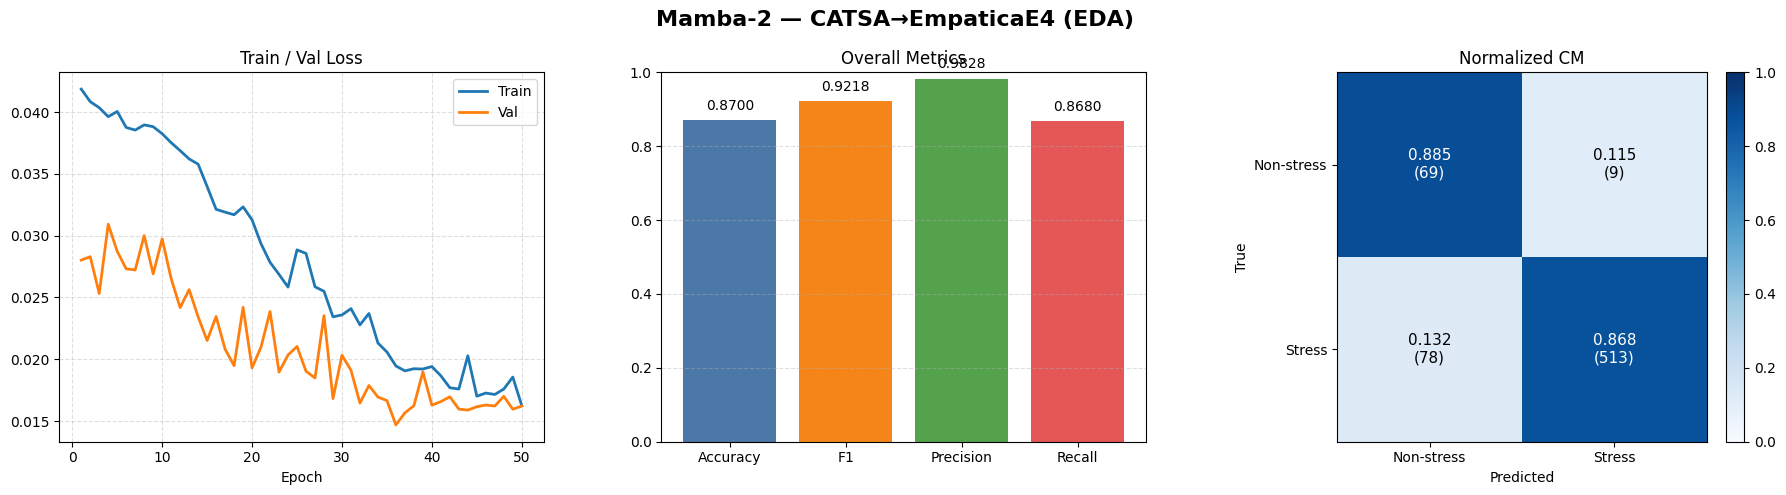

Saved results_1x3.png


In [10]:
# ── Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Train / Val Loss
axes[0].plot(range(1, len(train_losses)+1), train_losses, label="Train", linewidth=2)
axes[0].plot(range(1, len(val_losses)+1), val_losses, label="Val", linewidth=2)
axes[0].set_title("Train / Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.4)

# 2. Overall Metrics (Bar Chart)
bars = axes[1].bar(["Accuracy", "F1", "Precision", "Recall"],
                   [ov_acc, ov_f1, ov_prec, ov_rec],
                   color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])
axes[1].set_ylim(0, 1.0)
axes[1].set_title("Overall Metrics")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
for b, v in zip(bars, [ov_acc, ov_f1, ov_prec, ov_rec]):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.4f}",
                 ha="center", va="bottom", fontsize=10)

# 3. Normalized Confusion Matrix
cm_norm = ov_cm.astype(float) / ov_cm.sum(axis=1, keepdims=True).clip(1)
im = axes[2].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axes[2].set_title("Normalized CM")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Non-stress", "Stress"])
axes[2].set_yticklabels(["Non-stress", "Stress"])
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

thr = cm_norm.max() / 2
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cm_norm[i,j]:.3f}\n({ov_cm[i,j]})",
                     ha="center", va="center",
                     color="white" if cm_norm[i,j] > thr else "black", fontsize=11)

fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

# 제목 및 레이아웃 정리
fig.suptitle("Mamba-2 — CATSA→EmpaticaE4 (EDA)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "results_1x3.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved results_1x3.png")